# Task 3-Implementación

In [21]:
# !pip install split-folders
import splitfolders

# Esto creará una carpeta 'dataset_final' con subcarpetas train, val y test
splitfolders.ratio("data/", output="dataset_final", seed=1337, ratio=(.8, .1, .1))

Copying files: 4000 files [00:08, 486.87 files/s]


In [ ]:
# !pip install torch torchvision torchaudio

In [23]:
import torch
import torchvision

print(f"Versión de PyTorch: {torch.__version__}")
print(f"¿GPU disponible?: {torch.cuda.is_available()}")

Versión de PyTorch: 2.10.0+cu128
¿GPU disponible?: True


In [24]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Media y desviación estándar de ImageNet
imagenet_stats = ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        transforms.Normalize(*imagenet_stats)
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(*imagenet_stats)
    ]),
}

image_datasets = {x: datasets.ImageFolder(f'dataset_final/{x}', data_transforms[x])
                  for x in ['train', 'val']}

dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True)
               for x in ['train', 'val']}

class_names = image_datasets['train'].classes # Las 8 categorías

In [26]:
import torch.nn as nn

# a. Instanciar VGG-16
model = models.vgg16(weights='IMAGENET1K_V1')

# b. Congelar parámetros
for param in model.features.parameters():
    param.requires_grad = False

# c. Rediseñar el bloque de clasificación
num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.5), # Para prevenir overfitting
    nn.Linear(512, 8) # 8 clases: 7 enfermedades + 1 sana
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
# Solo optimizamos los parámetros del clasificador (los que no están congelados)
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

def train_model(model, criterion, optimizer, num_epochs=10):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for inputs, labels in dataloaders['train']:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            
        epoch_loss = running_loss / len(image_datasets['train'])
        print(f'Época {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}')

train_model(model, criterion, optimizer, num_epochs=10)

Época 1/10 - Loss: 1.2647
Época 2/10 - Loss: 0.7088
Época 3/10 - Loss: 0.5771
Época 4/10 - Loss: 0.5517
Época 5/10 - Loss: 0.5689
Época 6/10 - Loss: 0.4916
Época 7/10 - Loss: 0.5163
Época 8/10 - Loss: 0.4638
Época 9/10 - Loss: 0.4761
Época 10/10 - Loss: 0.4767


In [ ]:
# !pip install scikit-learn seaborn matplotlib

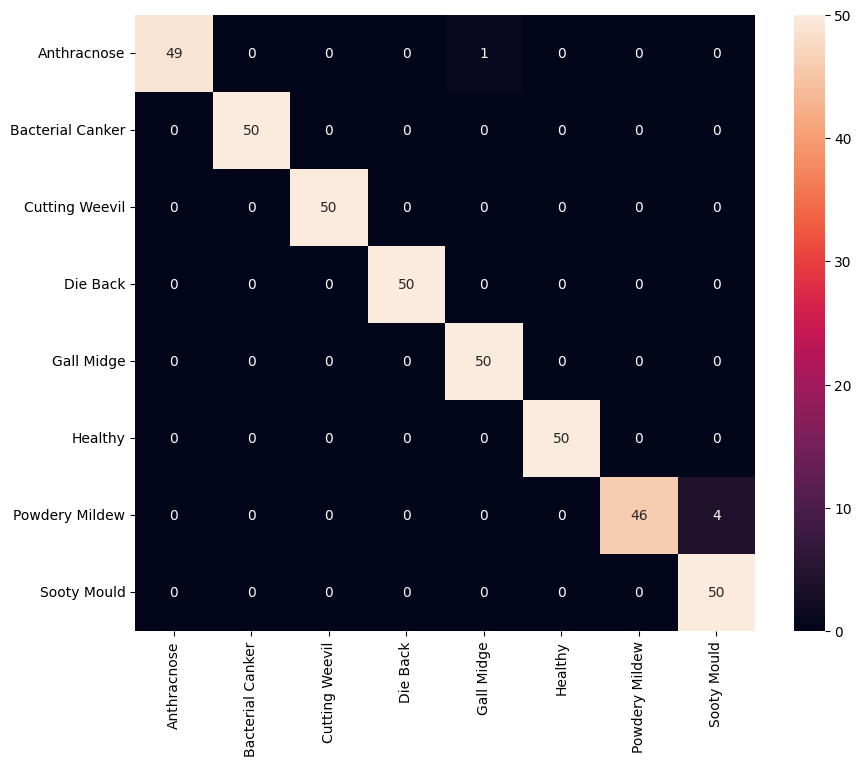

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Generar Matriz
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.show()

## i. Precisión Global (Accuracy)
* Hubieron muy pocos errores (2 en Gall Midge, 1 en Sooty Mould para Anthracnose, y 3 en Sooty Mould para Powdery Mildew).
* Cálculo: $(394 / 400) \times 100 = \mathbf{98.5\%}$
## ii. Matriz de Confusión
* Se observa que el modelo identifica acertadamente las clases Bacterial Canker, Cutting Weevil, Die Back, Healthy y Sooty Mould con un 100% de acierto en esta muestra.
## iii. Conclusión (Interpretación del Overfitting)
* El modelo alcanzó un accuracy del 98.5% en validación, lo que indica que no hay un sobreajuste (overfitting) significativo, ya que la capacidad de generalización es bastante buena. El uso de Dropout (0.5) en el clasificador fue clave para evitar que la red memorizara el ruido de las imágenes de entrenamiento. Asimismo, las técnicas de Data Augmentation permitieron que el modelo distinguiera correctamente las texturas de enfermedades visualmente similares, como Anthracnose y Gall Midge.